# MAGIC Example

In [10]:
"""
DataTypical Explorer
Finds and Explains Singificant Data Instances
"""
import os
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from datatypical import DataTypical
import datatypical_viz
from datatypical_viz import significance_plot, heatmap, profile_plot, get_top_sample

warnings.filterwarnings("ignore")
np.random.seed(42)

In [6]:
# ============================================================
# [1] Load MAGIC Gamma Telescope data
# ============================================================

DATA_PATH   = "magic04.data"
RANDOM_STATE = 42 
NMF_RANK = 8 
N_PERMUTATIONS = 50 
N_JOBS = -1 

MAGIC_COLS = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
t0_load = time.perf_counter()

df_full = pd.read_csv(DATA_PATH, header=None, names=MAGIC_COLS)

# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_full['class'] = le.fit_transform(df_full['class'])

print(f"Loaded MAGIC dataset: {len(df_full):,} instances, "
      f"{len(MAGIC_COLS) - 1} features, "
      f"classes: {df_full['class'].value_counts().to_dict()}")

# --- CHANGED: Skip train_test_split and use the full dataset ---
df = df_full.reset_index(drop=True) 
# ---------------------------------------------------------------

print(f"Dataset ready: {len(df):,} instances, "
      f"class distribution: {df['class'].value_counts().to_dict()}")

Loaded MAGIC dataset: 19,020 instances, 10 features, classes: {0: 12332, 1: 6688}
Dataset ready: 19,020 instances, class distribution: {0: 12332, 1: 6688}


In [8]:
# =====================================================================
# CONFIGURATION
# =====================================================================

dt = DataTypical(
    label_columns=['class'],
    stereotype_column='class',
    stereotype_target=0.999999, 
    fast_mode=False,
    archetypal_method = 'aa',
    shapley_mode=True,
    shapley_top_n=len(df), 
    shapley_n_permutations=100,
    random_state=42,
    n_jobs = -1,
    verbose=True
)

# Fit and transform
results = dt.fit_transform(df)
print("✓ DataTypical results complete!")


Publication mode defaults:
  archetypal_method: aa
  shapley_n_permutations: 100
  shapley_top_n: 19020
  shapley_compute_formative: True
Auto-detected data_type: 'tabular'

Fitting archetypal: Archetypal Analysis (PCHA+ConvexHull)
  Computing 8 archetypes using PCHA (stable in 10D)...
  PCHA converged, variance explained: 98.95%
  Stored: W =(19020, 8), H =(8, 10), n_archetypes =8

Fitting prototypes: Facility Location (k=20)
  Selected 20 prototypes, knee at 1

Stereotypical configuration:
  Target column: 'class'
  Target value: 0.999999
  Column range: [0.00, 1.00]
  Mean distance to target: 0.65

SHAPLEY DUAL-PERSPECTIVE ANALYSIS

[1] Computing Formative Instances (global perspective)...
    Using FULL dataset (required to measure structure)

  Computing Archetypal Formative (Cached Archetypes)...
    Samples: 19020, Features: 10
    Max permutations: 100
    100 perms, additivity error: 0.000000

  Computing Prototypical Formative (Coverage)...
    Samples: 19020, Features: 10
 

In [9]:
results

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class,archetypal_rank,prototypical_rank,stereotypical_rank,archetypal_shapley_rank,prototypical_shapley_rank,stereotypical_shapley_rank
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,0,0.440143,0.701304,0.000000,0.440149,0.071743,0.319201
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,0,0.533539,0.749379,0.000000,0.440149,0.071747,0.313531
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,0,0.569123,0.485612,0.000000,0.440214,0.071301,0.321639
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,0,0.522567,0.814537,0.000000,0.440149,0.071926,0.316992
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,0,0.527062,0.822560,0.000000,0.440149,0.072171,0.318835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,1,0.564539,0.711962,0.999999,0.440149,0.072426,0.337525
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,1,0.569843,0.629471,0.999999,0.440149,0.071771,0.342024
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,1,0.498505,0.638226,0.999999,0.440149,0.071737,0.341223
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,1,0.660299,0.477597,0.999999,0.440322,0.071592,0.342466


## Archetypes


 Creating significance plot...
    ✓ Saved: arch_significance_magic.png


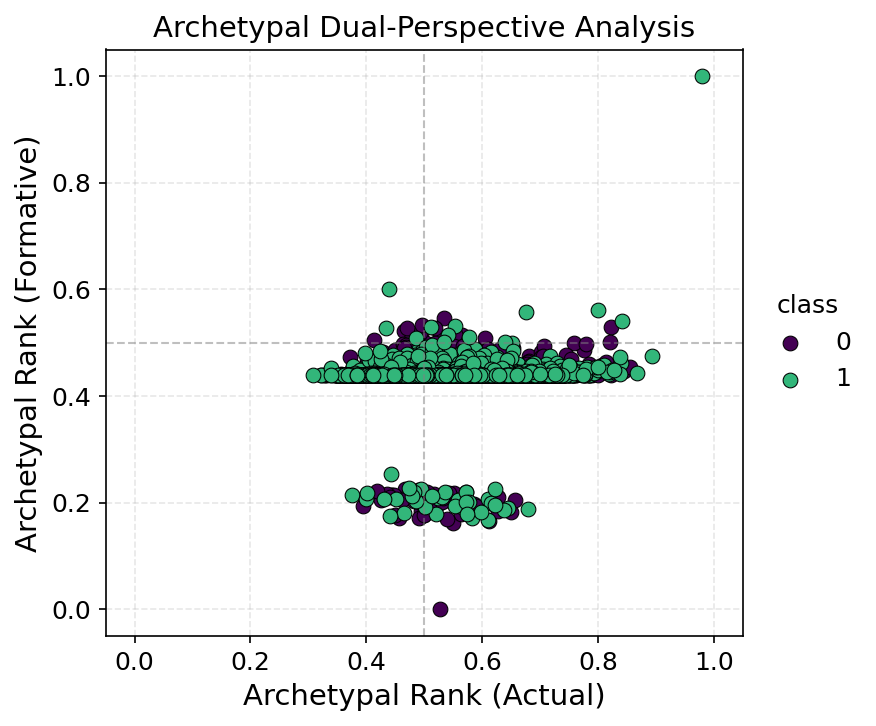

In [16]:
# ============================================================================
# Example 1: Archetypal Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='archetypal',
    color_by='class',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('arch_significance_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_significance_magic.png")


 Creating archetypal explanations heatmap...
    ✓ Saved: arch_heatmap_magic.png


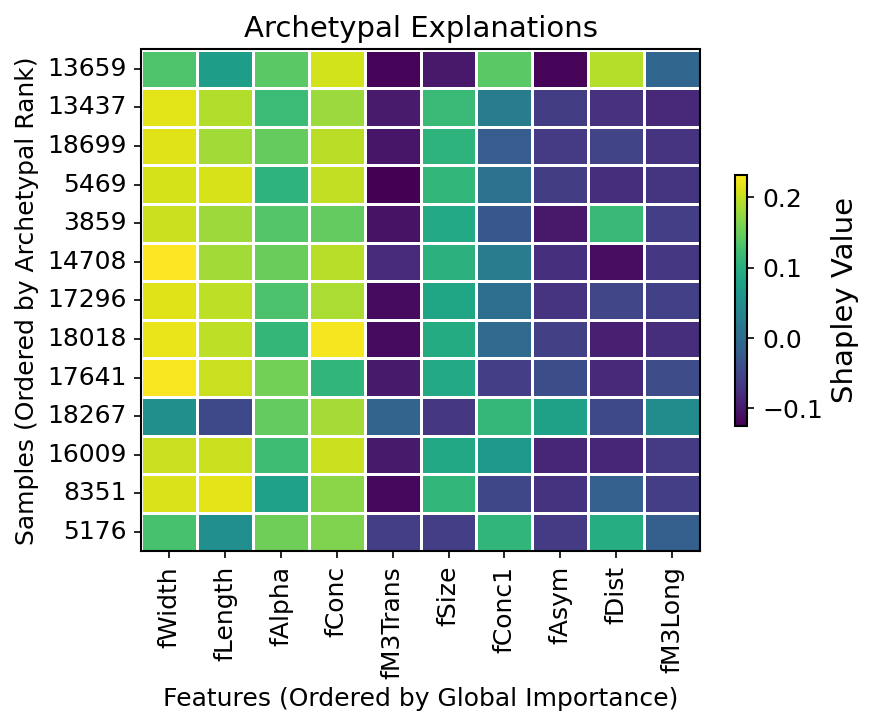

In [18]:
# ============================================================================
# Example 2: Heatmap - Archetypal Explanations
# ============================================================================
print("\n Creating archetypal explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='archetypal', 
    order='actual',
    top_n=13
)
ax.figure.savefig('arch_heatmap_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_heatmap_magic.png")


 Creating archetypal profile plot...
    Top archetype: 13659
fLength                       76.683900
fWidth                        37.432100
fSize                          3.589700
fConc                          0.094700
fConc1                         0.031000
fAsym                         66.048400
fM3Long                       64.690700
fM3Trans                     -10.949400
fAlpha                         0.831800
fDist                         21.124900
class                          1.000000
archetypal_rank                0.979296
prototypical_rank              0.467679
stereotypical_rank             0.999999
archetypal_shapley_rank        1.000000
prototypical_shapley_rank      0.071468
stereotypical_shapley_rank     0.335034
Name: 13659, dtype: float64
    ✓ Saved: arch_profile_magic.png


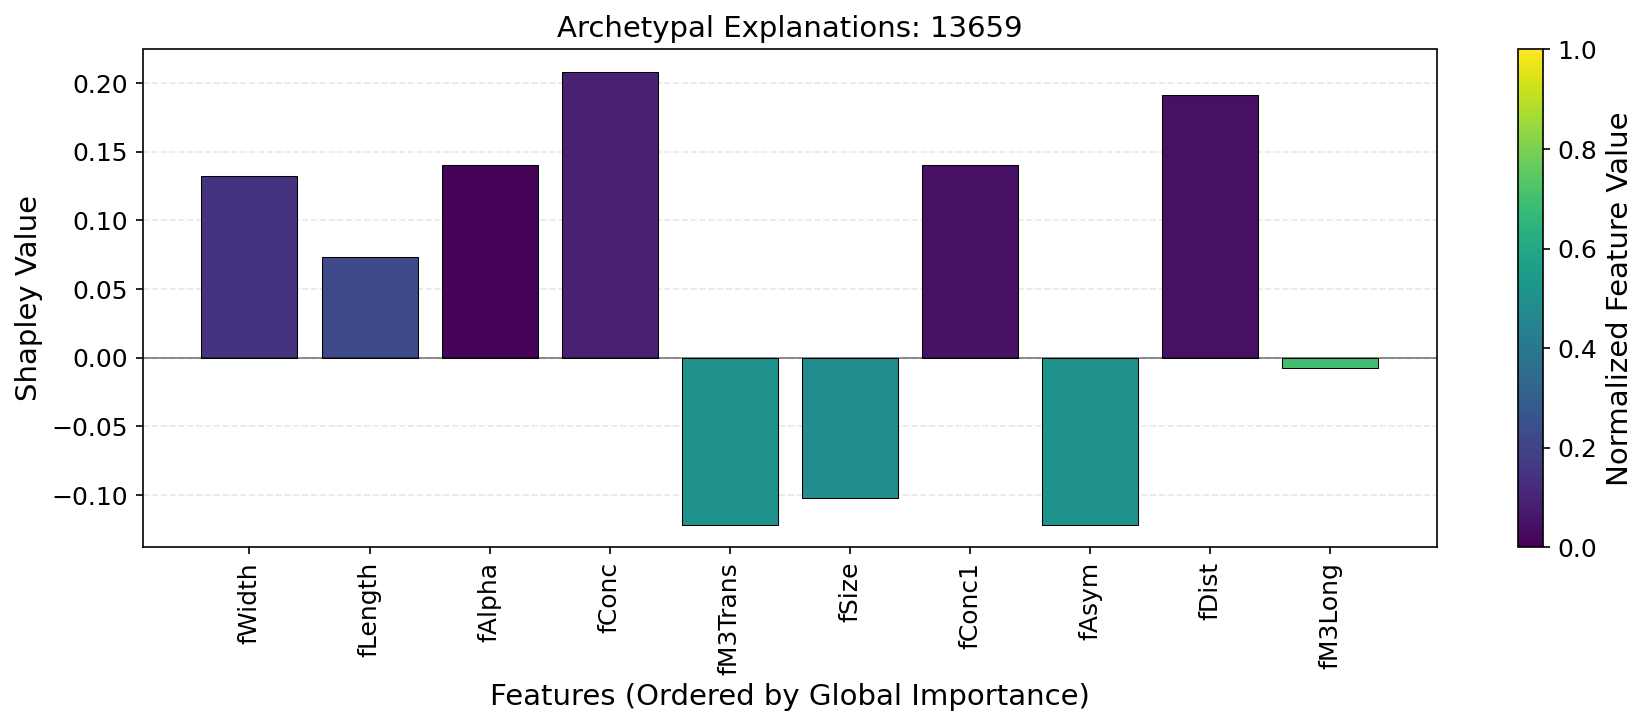

In [20]:
# ============================================================================
# Example 3a: Profile Plot - Top Archetype
# ============================================================================
print("\n Creating archetypal profile plot...")

top_arch_idx = results['archetypal_rank'].idxmax()
print(f"    Top archetype: {top_arch_idx}\n{results.loc[top_arch_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_arch_idx,
    significance='archetypal', 
    order='global'
)
ax.figure.savefig('arch_profile_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_profile_magic.png")



 Creating archetypal profile plot...
    Top formative archetype: 13659
fLength                       76.683900
fWidth                        37.432100
fSize                          3.589700
fConc                          0.094700
fConc1                         0.031000
fAsym                         66.048400
fM3Long                       64.690700
fM3Trans                     -10.949400
fAlpha                         0.831800
fDist                         21.124900
class                          1.000000
archetypal_rank                0.979296
prototypical_rank              0.467679
stereotypical_rank             0.999999
archetypal_shapley_rank        1.000000
prototypical_shapley_rank      0.071468
stereotypical_shapley_rank     0.335034
Name: 13659, dtype: float64
    ✓ Saved: arch_form_magic.png


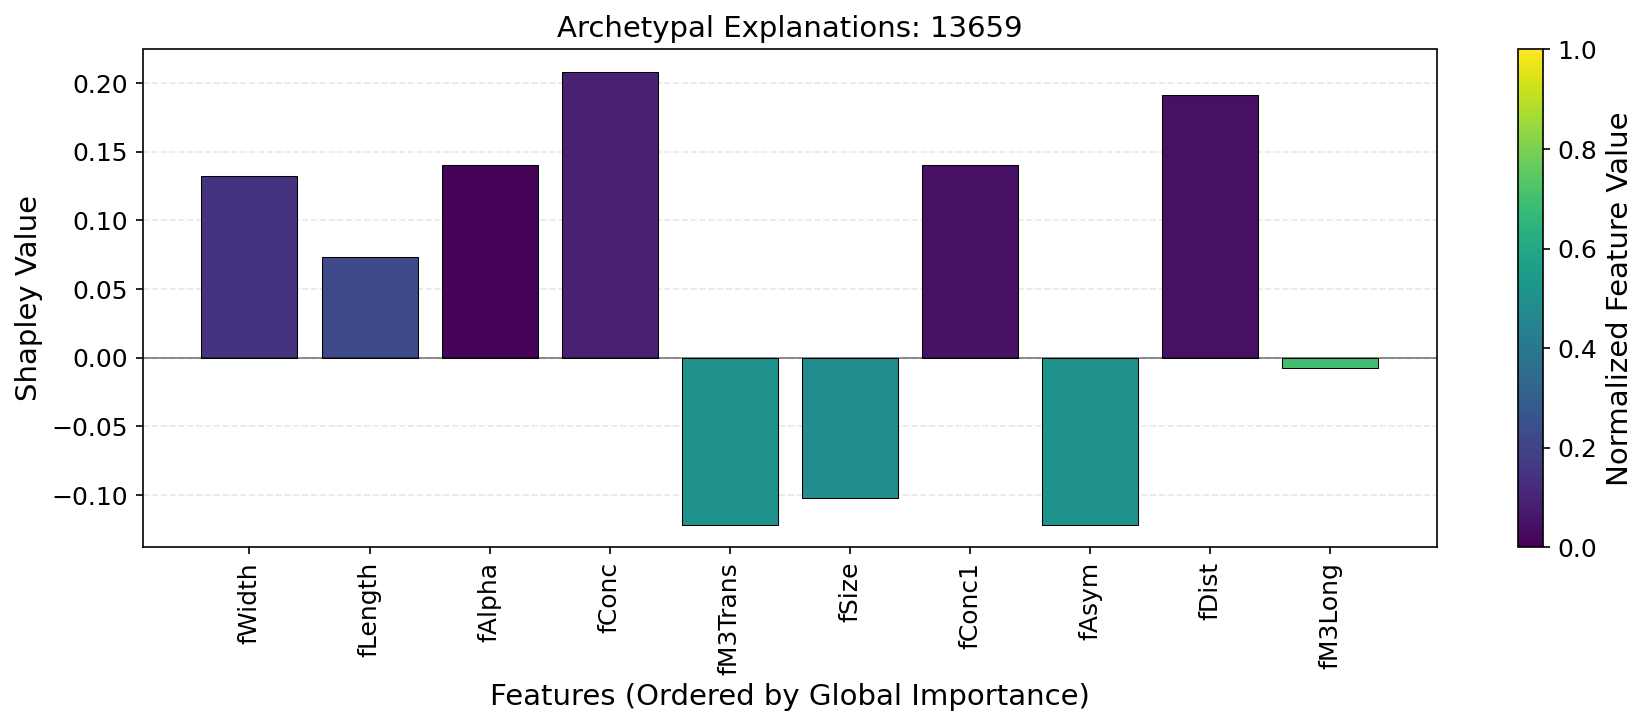

In [21]:
# ============================================================================
# Example 3b: Profile Plot - Top Formative Archetype
# ============================================================================
print("\n Creating archetypal profile plot...")

top_arch_idx = results['archetypal_shapley_rank'].idxmax()
print(f"    Top formative archetype: {top_arch_idx}\n{results.loc[top_arch_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_arch_idx,
    significance='archetypal', 
    order='global'
)
ax.figure.savefig('arch_form_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: arch_form_magic.png")


## Prototypes


 Creating significance plot...
    ✓ Saved: proto_significance_magic.png


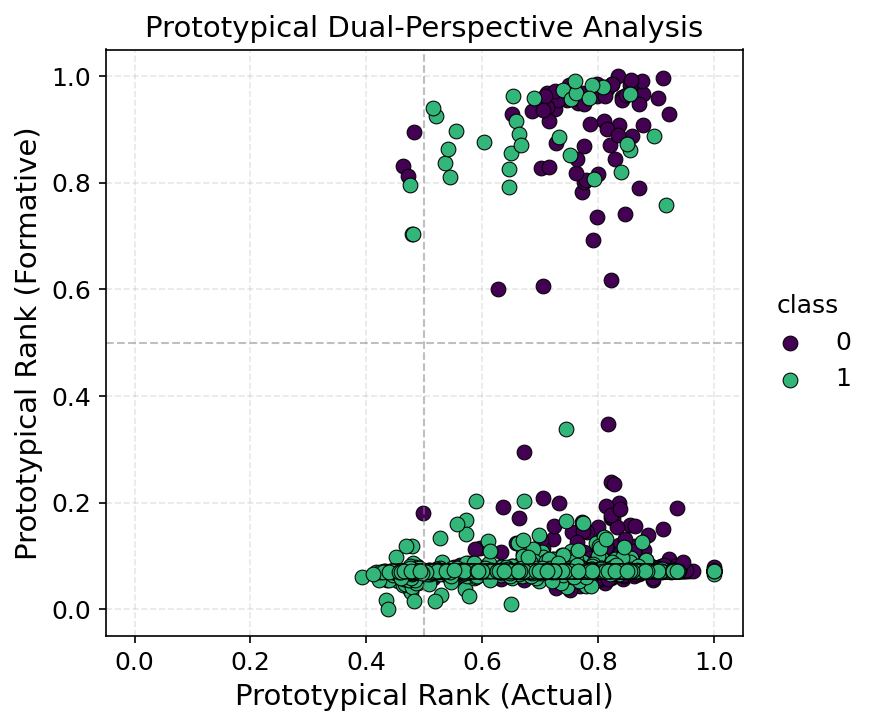

In [24]:
# ============================================================================
# Example 4: Prototypical Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='prototypical',
    color_by='class',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('proto_significance_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_significance_magic.png")


 Creating prototypical explanations heatmap...
    ✓ Saved: proto_heatmap_magic.png


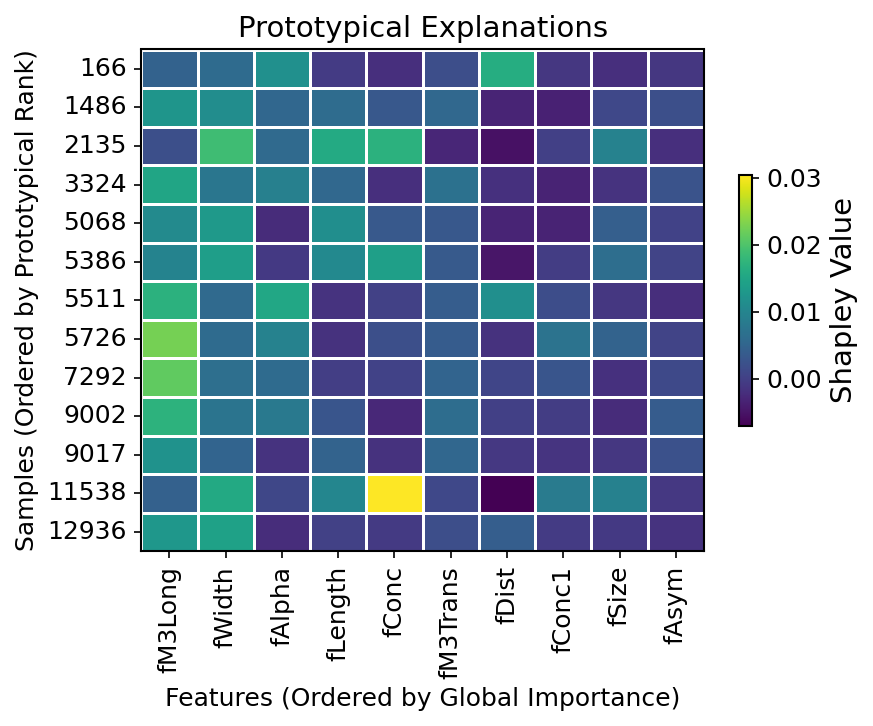

In [25]:
# ============================================================================
# Example 5: Heatmap - Prototypical Explanations
# ============================================================================
print("\n Creating prototypical explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='prototypical', 
    order='actual',
    top_n=13
)
ax.figure.savefig('proto_heatmap_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_heatmap_magic.png")



 Creating prototpyical profile plot...
    Top prototype: 166
fLength                        85.935500
fWidth                         29.921500
fSize                           3.075500
fConc                           0.313400
fConc1                          0.173500
fAsym                         -44.050800
fM3Long                       -20.065900
fM3Trans                      -14.117000
fAlpha                          4.759700
fDist                         335.983000
class                           0.000000
archetypal_rank                 0.518947
prototypical_rank               1.000000
stereotypical_rank              0.000000
archetypal_shapley_rank         0.440149
prototypical_shapley_rank       0.071804
stereotypical_shapley_rank      0.319310
Name: 166, dtype: float64
    ✓ Saved: proto_profile_magic.png


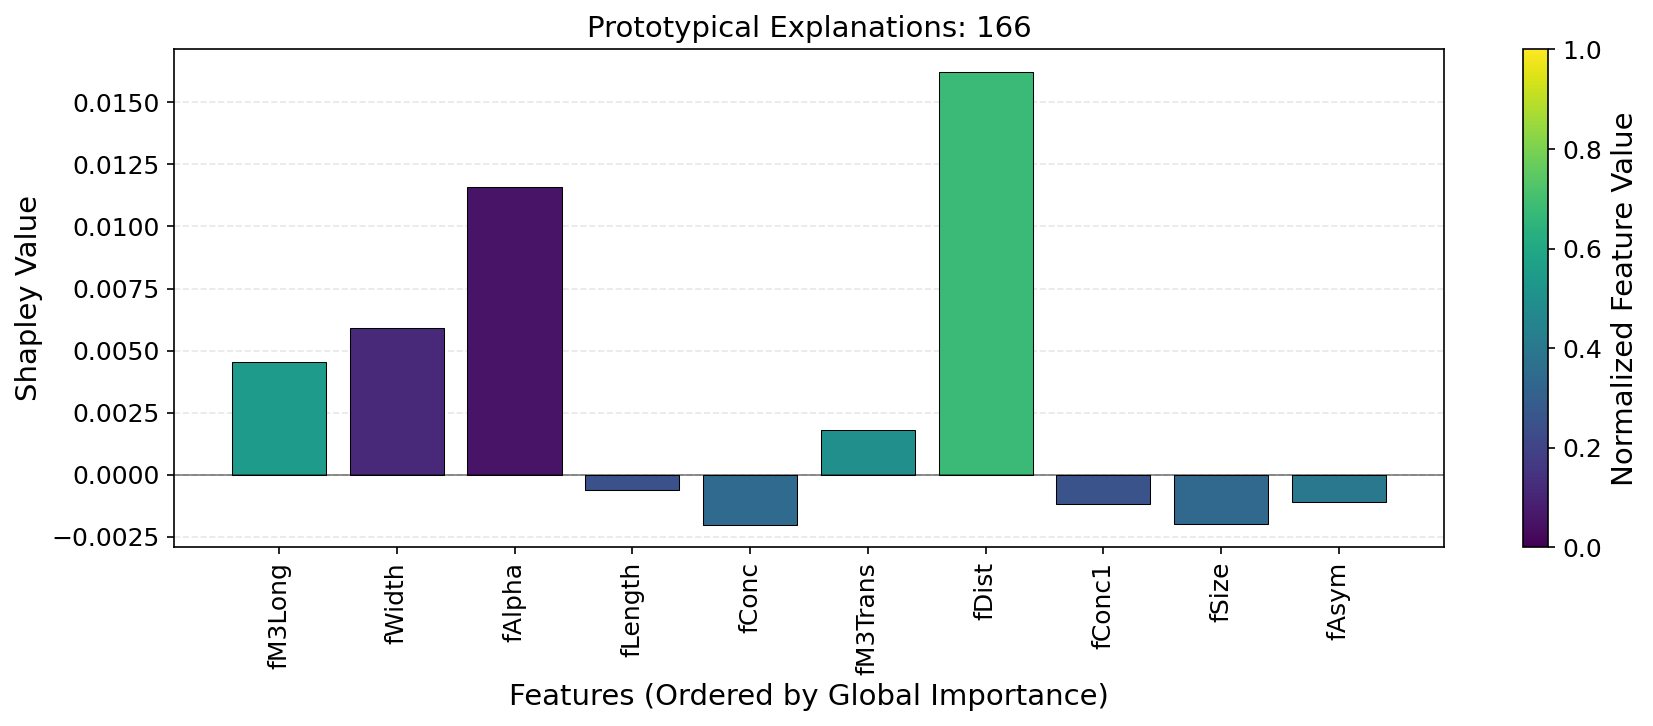

In [26]:
# ============================================================================
# Example 6a: Profile Plot - Top Prototype
# ============================================================================
print("\n Creating prototpyical profile plot...")

top_proto_idx = results['prototypical_rank'].idxmax()
print(f"    Top prototype: {top_proto_idx}\n{results.loc[top_proto_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_proto_idx,
    significance='prototypical', 
    order='global'
)
ax.figure.savefig('proto_profile_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_profile_magic.png")



 Creating prototpyical profile plot...
    Top formative prototype: 614
fLength                        22.083700
fWidth                         10.526500
fSize                           2.173200
fConc                           0.563800
fConc1                          0.312100
fAsym                         -22.605600
fM3Long                       -18.892500
fM3Trans                       10.737600
fAlpha                         14.439700
fDist                         172.572000
class                           0.000000
archetypal_rank                 0.466426
prototypical_rank               0.835323
stereotypical_rank              0.000000
archetypal_shapley_rank         0.440149
prototypical_shapley_rank       1.000000
stereotypical_shapley_rank      0.309757
Name: 614, dtype: float64
    ✓ Saved: proto_form_magic.png


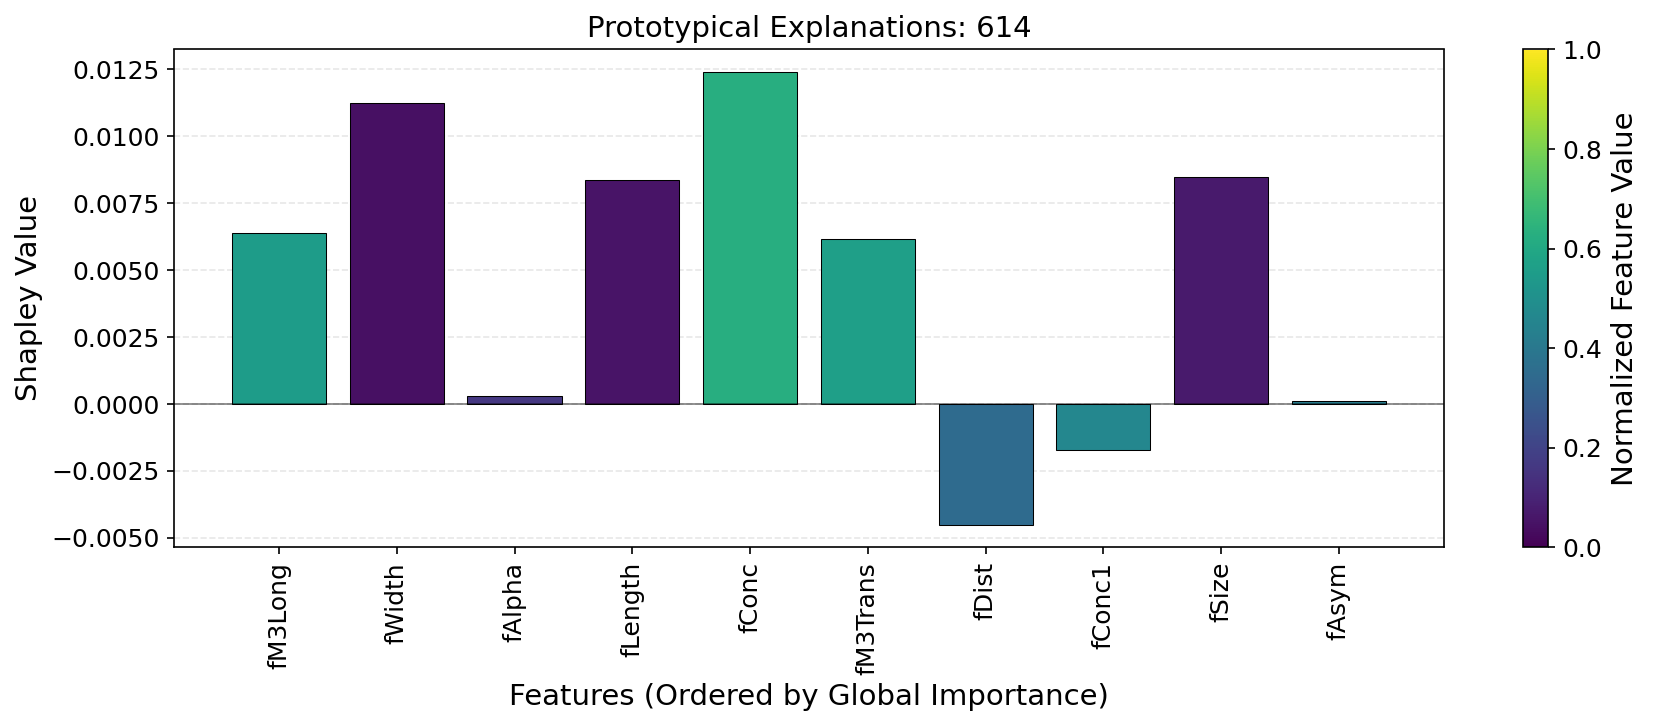

In [29]:
# ============================================================================
# Example 6b: Profile Plot - Top Formative Prototype
# ============================================================================
print("\n Creating prototpyical profile plot...")

top_proto_idx = results['prototypical_shapley_rank'].idxmax()
print(f"    Top formative prototype: {top_proto_idx}\n{results.loc[top_proto_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_proto_idx,
    significance='prototypical', 
    order='global'
)
ax.figure.savefig('proto_form_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: proto_form_magic.png")


## Stereotypes


 Creating significance plot...
    ✓ Saved: stereo_significance_magic.png


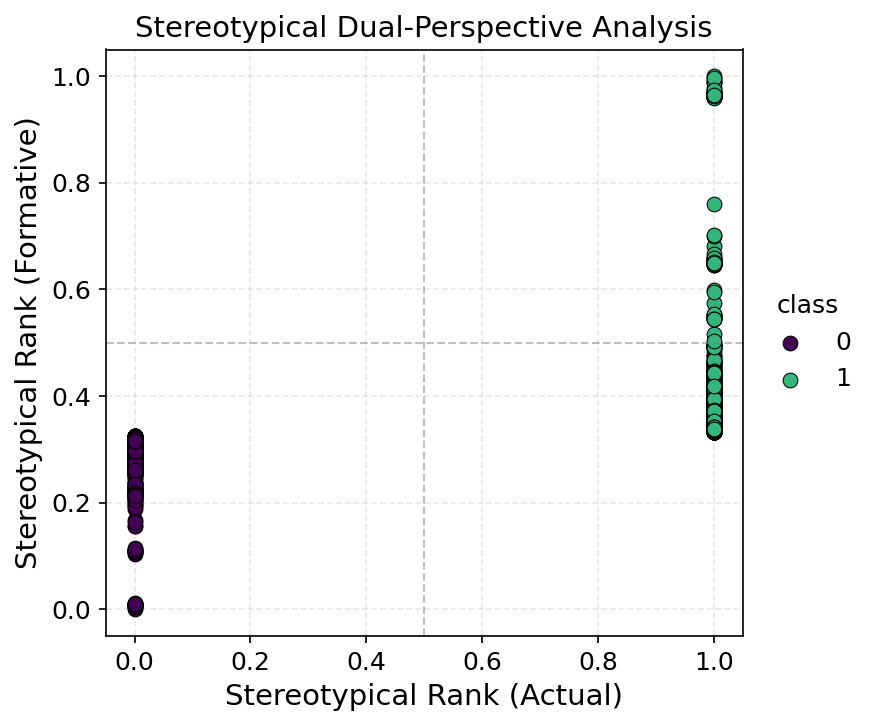

In [35]:
# ============================================================================
# Example 7: Stereotypical Significance Plot (Dual-Perspective Scatter)
# ============================================================================
print("\n Creating significance plot...")

ax = significance_plot(
    results,
    significance='stereotypical',
    color_by='class',
    quadrant_lines=True,
    quadrant_threshold = (0.5,0.5)
)
ax.figure.savefig('stereo_significance_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_significance_magic.png")


 Creating stereotypical explanations heatmap...
    ✓ Saved: stereo_heatmap_magic.png


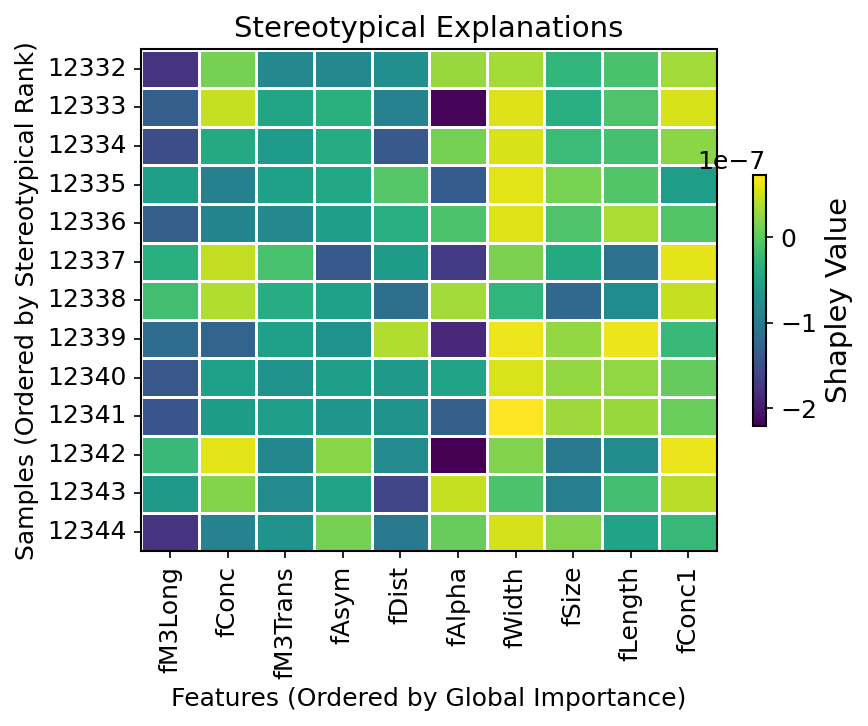

In [36]:
# ============================================================================
# Example 8: Heatmap - Stereotypical Explanations
# ============================================================================
print("\n Creating stereotypical explanations heatmap...")

ax = heatmap(
    dt,
    results=results,
    significance='stereotypical', 
    order='actual',
    top_n=13
)
ax.figure.savefig('stereo_heatmap_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_heatmap_magic.png")



 Creating stereotypical profile plot...
    Top stereotype: 12332
fLength                        93.703500
fWidth                         37.943200
fSize                           3.145400
fConc                           0.168000
fConc1                          0.101100
fAsym                          53.256600
fM3Long                        89.056600
fM3Trans                       11.817500
fAlpha                         14.122400
fDist                         231.902800
class                           1.000000
archetypal_rank                 0.501804
prototypical_rank               0.850826
stereotypical_rank              0.999999
archetypal_shapley_rank         0.440149
prototypical_shapley_rank       0.071810
stereotypical_shapley_rank      0.341517
Name: 12332, dtype: float64
    ✓ Saved: stereo_profile_magic.png


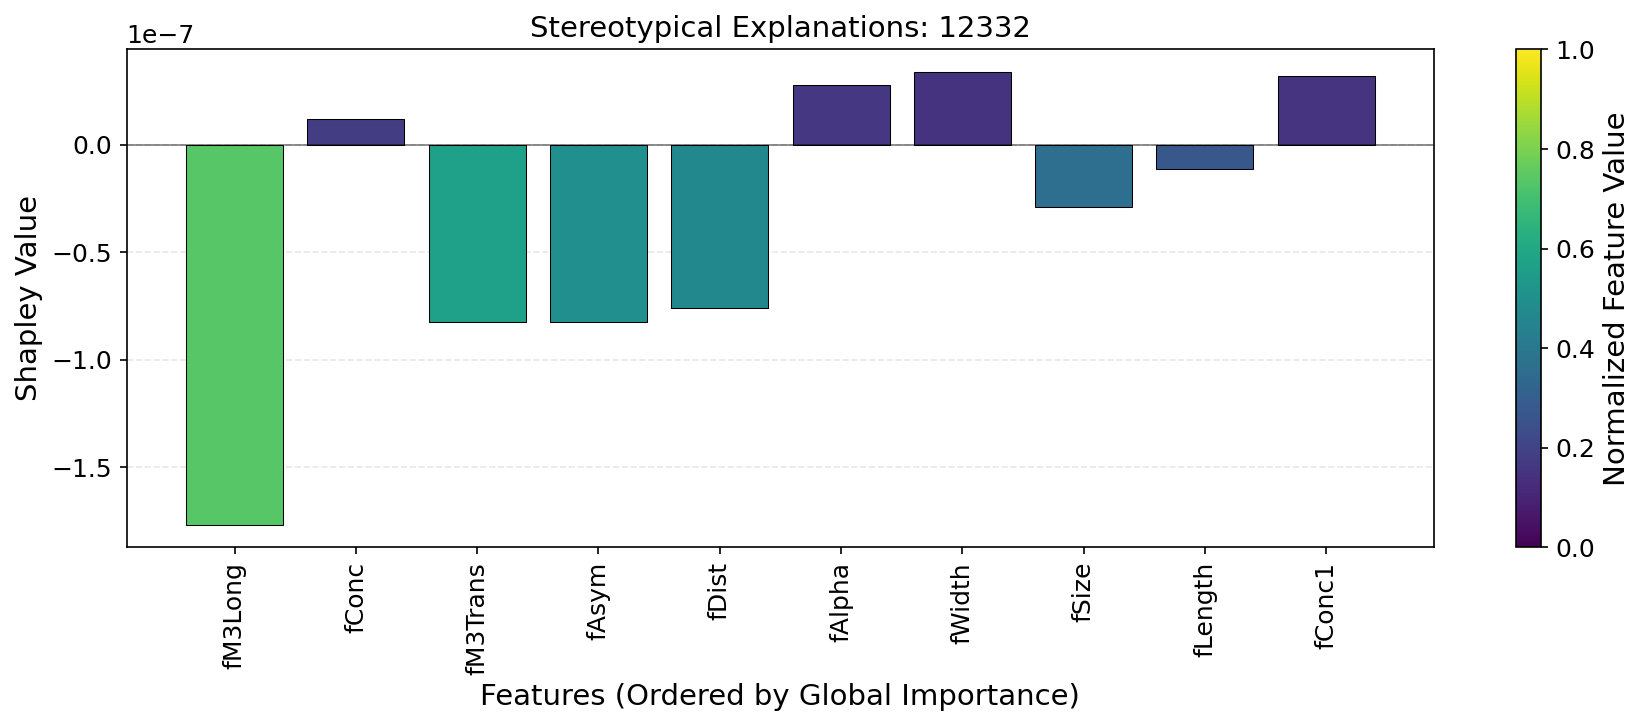

In [39]:
# ============================================================================
# Example 9a: Profile Plot - Top Stereotype
# ============================================================================
print("\n Creating stereotypical profile plot...")

top_stereo_idx = results['stereotypical_rank'].idxmax()
print(f"    Top stereotype: {top_stereo_idx}\n{results.loc[top_stereo_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_stereo_idx,
    significance='stereotypical', 
    order='global'
)
ax.figure.savefig('stereo_profile_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_profile_magic.png")



 Creating stereotypical formative profile plot...
    Top formative stereotype: 14198
fLength                       239.756000
fWidth                         88.076000
fSize                           3.601100
fConc                           0.119500
fConc1                          0.061800
fAsym                        -207.103000
fM3Long                      -274.828000
fM3Trans                       55.961500
fAlpha                         17.882000
fDist                         283.184000
class                           1.000000
archetypal_rank                 0.518776
prototypical_rank               0.472168
stereotypical_rank              0.999999
archetypal_shapley_rank         0.454948
prototypical_shapley_rank       0.071368
stereotypical_shapley_rank      1.000000
Name: 14198, dtype: float64
    ✓ Saved: stereo_form_magic.png


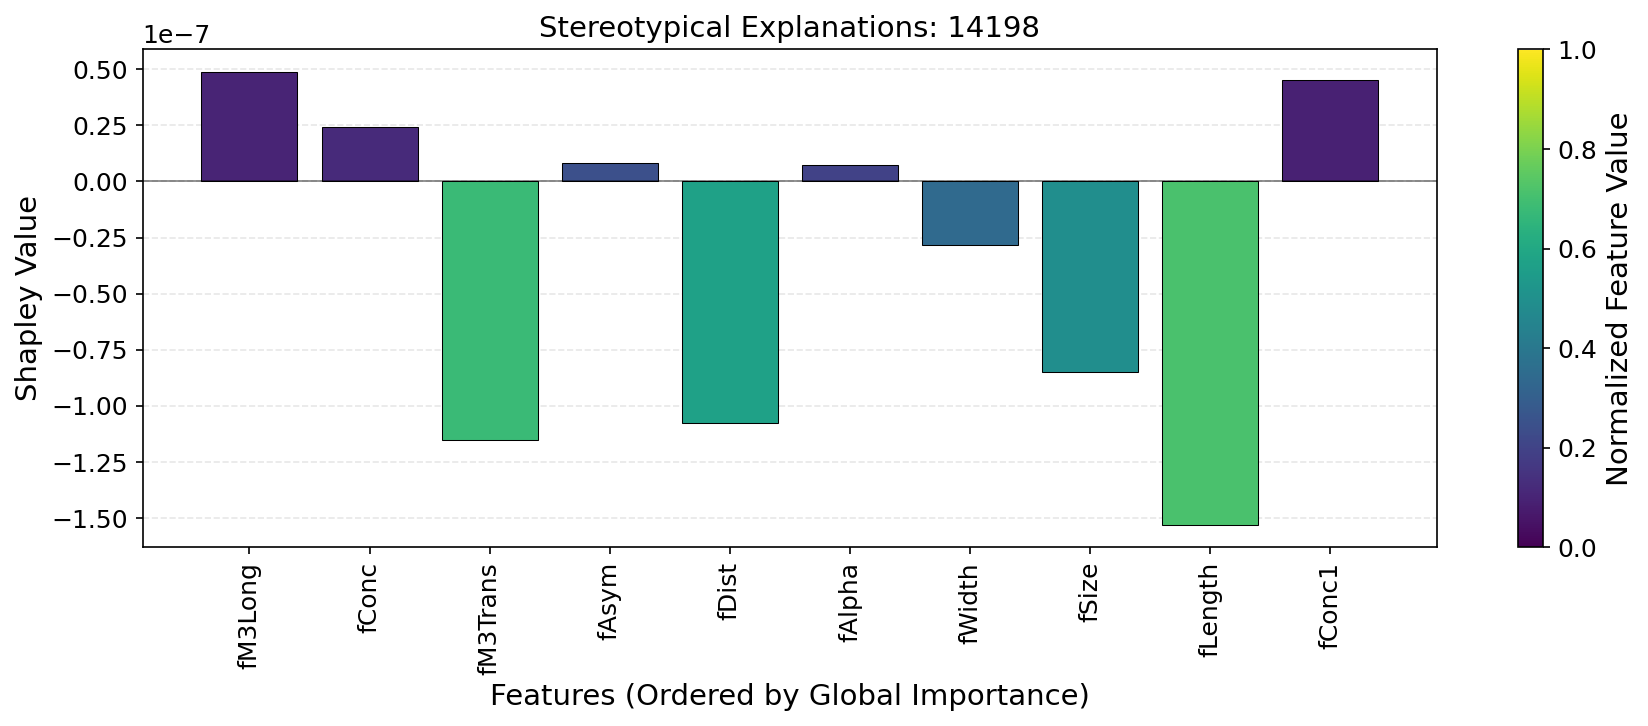

In [41]:
# ============================================================================
# Example 9b: Profile Plot - Top Formative Stereotype
# ============================================================================
print("\n Creating stereotypical formative profile plot...")

top_stereo_idx = results['stereotypical_shapley_rank'].idxmax()
print(f"    Top formative stereotype: {top_stereo_idx}\n{results.loc[top_stereo_idx]}")

ax = profile_plot(
    dt,
    sample_idx=top_stereo_idx,
    significance='stereotypical', 
    order='global'
)
ax.figure.savefig('stereo_form_magic.png', dpi=300, bbox_inches='tight')
print("    ✓ Saved: stereo_form_magic.png")


In [42]:
import pickle

# Save the model
with open('magic_dt.pkl', 'wb') as file:
    pickle.dump(dt, file)

# Save the results
with open('magic_results.pkl', 'wb') as file:
    pickle.dump(results, file)

# # Load the model
# with open('magic_dt.pkl', 'rb') as file:
#     dt = pickle.load(file)

# # Load the results
# with open('magic_results.pkl', 'rb') as file:
#     results = pickle.load(file)